# 01. Frictionless Historical Baselines
**Objective:** Evaluate the historical performance of standard mathematical portfolio models (MVO, HRP, RP, IVP, EW) on the raw dataset, assuming zero transaction costs and no dynamic turnover constraints. The models will be compared based on their performance on the period between 2016 and 2021 to ensure a fair comparison. This is done, since the HMM models and Monte Carlo simulators are trained on market data between 2005 and 2015, thus by using later data we can eliminate potential data leakage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from model_setup import models_to_test_frictionless

In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{lmodern} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{amssymb}",
        "font.family": "serif",
        "font.serif": ["Latin Modern Roman"],
    }
)

In [3]:
stock_data = pd.read_csv(
    "../data/raw/stock_data_comparison.csv", index_col=0, parse_dates=True
)

In [4]:
tested_models = []

In [5]:
for model in models_to_test_frictionless:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_models.append(testing_model)

First we can examine the performance of the different methods relative to each other independent of the specific estimator being in use.

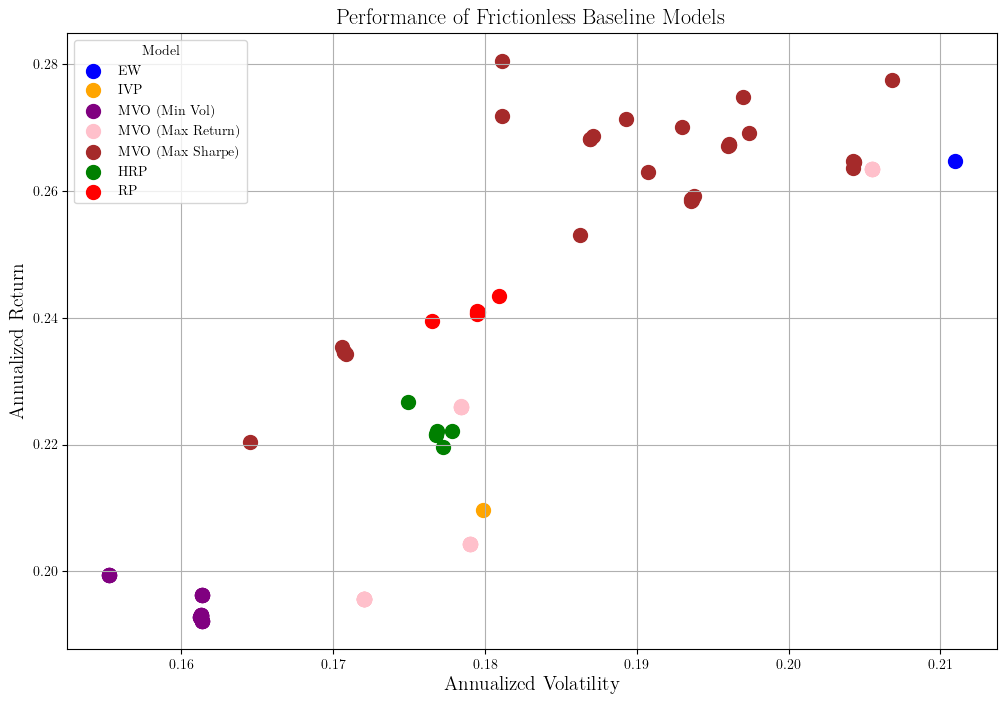

In [6]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Frictionless Baseline Models", fontsize=16)

for i, model in enumerate(tested_models):
    name = models_to_test_frictionless[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:9] == "MVO_min_v":
            name = "MVO (Min Vol)"
        elif name[:9] == "MVO_max_s":
            name = "MVO (Max Sharpe)"
        elif name[:9] == "MVO_max_r":
            name = "MVO (Max Return)"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO (Min Vol)":
        color = "purple"
    elif name == "MVO (Max Sharpe)":
        color = "brown"
    elif name == "MVO (Max Return)":
        color = "pink"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")
plt.show()

The equal weighted portfolio performs suprisingly well showing strong average annual returns, but posting a relatively high volatility. Similarly the inverse volatility weighted portfolio performed reasonably well getting decent returns for its volatility class compared to more sophisticated methods.

Hierarchical risk parity methods showed consistent volatility independent of which covariance method was used. Traditional Risk parity methods posted higher volatility and slightly higher returns than HRP depending on the covariance estimator.

Generaly Mean Variance Optimization performed the best. In low volatility scenarios HRP / RP could produce higher returns for the same volatility, but MVO produced the portfolios with the least volatiltiy. Similarly if we allow higher volatilities MVO with the maximum sharpe ratio objective performed well in general, independent of the specific estimator being used.

Between the different MVO objectives we can see an interesting pattern. The maximum Sharpe Ratio objective ones produced the best return, albeit at higher volatility, and we can see a large variation based on what kind of estimators were used. The other two objectives yielded approximately the same performance independent of the different estimators. Surprisingly the maximum return objective produced worse outcomes than the maximum sharpe objective.

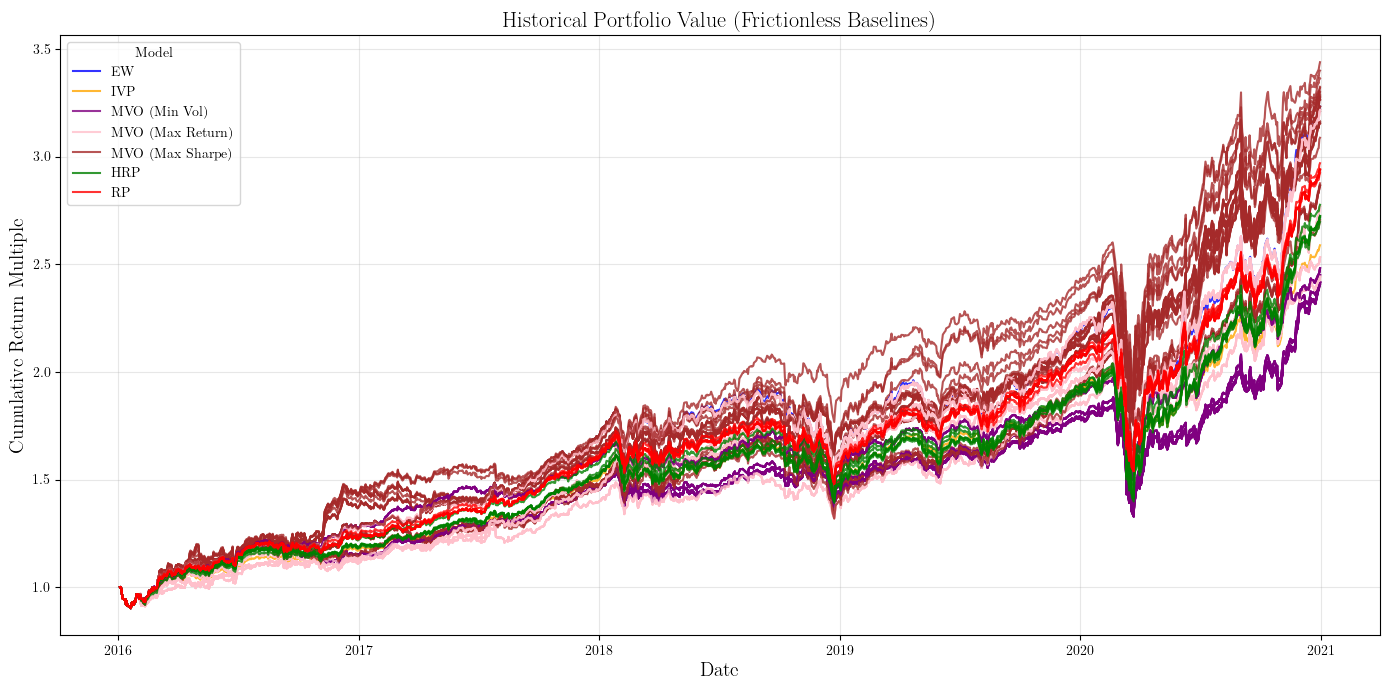

In [7]:
fig = plt.figure(figsize=(14, 7))
plt.title("Historical Portfolio Value (Frictionless Baselines)", fontsize=16)

for i, model in enumerate(tested_models):
    name = models_to_test_frictionless[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:9] == "MVO_min_v":
            name = "MVO (Min Vol)"
        elif name[:9] == "MVO_max_s":
            name = "MVO (Max Sharpe)"
        elif name[:9] == "MVO_max_r":
            name = "MVO (Max Return)"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO (Min Vol)":
        color = "purple"
    elif name == "MVO (Max Sharpe)":
        color = "brown"
    elif name == "MVO (Max Return)":
        color = "pink"

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data.index,
        normalized_pv,
        label=name,
        alpha=0.8,
        linewidth=1.5,
        color=color,
    )

plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative Return Multiple", fontsize=14)
plt.grid(True, alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

plt.tight_layout()
plt.show()

Looking at the cummulative wealth of the portfolios we can draw a similar conclusion. Surprisingly all methods experienced serious drawdown as covid started.

In [8]:
metrics_list = []
for i, model in enumerate(tested_models):
    metrics = model.performance_metrics.copy()
    metrics["Model"] = models_to_test_frictionless[i]["name"]
    metrics_list.append(metrics)

df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics.round(4)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,VAR (95%),ES (95%),Skewness,Kurtosis
Model,,,,,,,,,,
EW,0.2647,0.2109,1.2547,1.4565,0.3315,0.7983,0.0188,0.0326,-0.6447,16.5594
MVO_max_return_historical_cov_equilibrium_ret,0.2634,0.2055,1.2815,1.4881,0.3204,0.8220,0.0180,0.0319,-0.5929,16.1908
MVO_max_return_ledoit_wolf_cov_equilibrium_ret,0.2634,0.2055,1.2815,1.4881,0.3204,0.8220,0.0180,0.0319,-0.5929,16.1908
MVO_max_return_FF_3_cov_equilibrium_ret,0.2634,0.2055,1.2815,1.4881,0.3204,0.8220,0.0180,0.0319,-0.5929,16.1908
MVO_max_return_FF_5_cov_equilibrium_ret,0.2634,0.2055,1.2815,1.4881,0.3204,0.8220,0.0180,0.0319,-0.5929,16.1908
...,...,...,...,...,...,...,...,...,...,...
MVO_max_sharpe_Carhart_4_cov_FF_3_ret,0.2585,0.1936,1.3349,1.6381,0.2252,1.1476,0.0180,0.0294,0.0436,14.5026
MVO_max_sharpe_FF_3_cov_FF_3_ret,0.2588,0.1936,1.3365,1.6393,0.2252,1.1490,0.0180,0.0294,0.0436,14.5091
MVO_max_sharpe_FF_5_cov_FF_3_ret,0.2584,0.1936,1.3349,1.6371,0.2252,1.1475,0.0180,0.0294,0.0437,14.5182


Looking at the broader performance metrics we can draw similar conclusions, in general the naive allocation methods are competitive, but generally the best performance is produced by the MVO portfolios. Espescially those models that use some form of factor model to estimate either returns or covariance. Interestingly the best drawdown is also produced by an MVO model using the max Sharpe ratio objective. 

Thus based on their performance in a frinctionless environment, the maximum Sharpe Ratio objective of the MVO models seems to produce the best results, especially with factor based modelling.